In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field, SkipValidation
from typing_extensions import TypedDict
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import END, StateGraph, START
from langchain_tavily import TavilySearch

from dotenv import load_dotenv

In [3]:
KNOWLEDGE_BASE_URLS = [
    "https://www.linkedin.com/pulse/word-embeddings-how-neural-net-understands-words-space-prateek-sbl5c/",
    "https://www.linkedin.com/pulse/dissecting-backpropagation-neural-networks-saurav-prateek-krcvc/"
]

In [4]:
# Data model
class SharedState(TypedDict):
    """ Shared state for the RAG system. """
    question: str
    agent_response: str
    vector_store: Chroma
    relevant_documents: list[str]
    model: ChatGoogleGenerativeAI

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [5]:
def get_model(shared_state):
    shared_state['model'] = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    return shared_state


In [16]:
import uuid
import chromadb

def build_vector_store(state):
    """
    Build a vector store from the knowledge base URLs.
    """
    print("---BUILD VECTOR STORE---")
    collection_name = 'gemini_fixed_collection'
    chroma_client = chromadb.EphemeralClient()
    embedding_model_name = 'gemini-embedding-2'
    embeddings_model = GoogleGenerativeAIEmbeddings(model=embedding_model_name)

    try:
        collection = chroma_client.get_collection(collection_name)
        vector_store = Chroma(
            client=chroma_client,
            collection_name=collection_name,
            embedding_function=embeddings_model
        )
        state['vector_store'] = vector_store.as_retriever()
        print('Collection already exist, picking from the cache!')
        return state
    except:
        print('Collection does not exist, creating a new one!')


    docs = [WebBaseLoader(url).load() for url in KNOWLEDGE_BASE_URLS]
    docs_list = [item for sublist in docs for item in sublist]

    text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        chunk_size=250, chunk_overlap=0
    )
    doc_splits = text_splitter.split_documents(docs_list)

    embeddings = [embeddings_model.embed_query(chunk.page_content) for chunk in doc_splits]

    text_embedding_pairs = list(zip(doc_splits, embeddings))
    collection = chroma_client.create_collection(name=collection_name)

    collection.add(
        documents=[chunk.page_content for chunk in doc_splits],
        embeddings=embeddings,
        metadatas=[chunk.metadata for chunk in doc_splits],
        ids=[str(uuid.uuid4()) for _ in doc_splits]
    )

    vector_store = Chroma(
        client=chroma_client,
        collection_name=collection_name,
        embedding_function=embeddings_model
    )
    state['vector_store'] = vector_store.as_retriever()
    return state

In [8]:
def get_relevant_documents(shared_state):
    """
    Get relevant documents from the vector store.
    """
    question = shared_state["question"]
    vector_store = shared_state["vector_store"]

    documents = vector_store.invoke(question)
    shared_state["relevant_documents"] = [doc.page_content for doc in documents]

    return shared_state


In [9]:
GRADE_DOCUMENTS_PROMPT = """
    You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
"""

def grade_and_filter_documents(shared_state):
    """
    Grade the relevance of retrieved documents to a user question.
    """
    print("\n\n Grading documents for relevance... \n")
    question = shared_state['question']
    model = shared_state['model']
    documents = shared_state['relevant_documents']
    structured_llm_grader = model.with_structured_output(GradeDocuments)

    grade_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", GRADE_DOCUMENTS_PROMPT),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
        ]
    )

    retrieval_grader = grade_prompt | structured_llm_grader
    filtered_documents = []

    for document in documents:
        grader_response = retrieval_grader.invoke({"question": question, "document": document})
        if grader_response.binary_score.lower() == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_documents.append(document)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
    
    print("Relevant documents left after filtering:", len(filtered_documents))
    shared_state['relevant_documents'] = filtered_documents

    return shared_state


In [10]:
ANSWER_GENERATION_PROMPT = """
You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
"""

def generate_answer_from_documents(shared_state):
    """ Generate an answer to the question using the relevant documents. """
    model = shared_state['model']
    rag_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", ANSWER_GENERATION_PROMPT),
            ("human", "Question: \n\n {question} \n\n Context: {context}"),
        ]
    )
    question = shared_state['question']
    documents = shared_state['relevant_documents']

    rag_chain = rag_prompt | model | StrOutputParser()

    model_response = rag_chain.invoke({"context": documents, "question": question})
    shared_state['agent_response'] = model_response

    return shared_state

In [11]:
def decide_to_generate(shared_state):
    """ Decide whether to generate an answer or perform a web search. """
    if len(shared_state['relevant_documents']) > 0:
        print("\n Generating answer from relevant documents... \n\n")
        return "generate"
    else:
        print("\n No relevant documents found, transform query and performing web search... \n\n")
        return "transform_query"


In [23]:
QUESTION_REWRITER_PROMPT = """
    You a question re-writer that converts an input question to a better version that is optimized. \n 
    for web search. Look at the input and try to reason about the underlying semantic intent / meaning.
    STRICT: Keep the question crisp and under 400 characters.
"""

def transform_query(shared_state):
    """
    Transform the query to produce a better question.
    """

    print("\n\n ---TRANSFORMING QUERY---")
    question = shared_state["question"]
    model = shared_state["model"]

    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", QUESTION_REWRITER_PROMPT),
            (
                "human",
                "Here is the initial question: \n\n {question} \n Formulate an improved question.",
            ),
        ]
    )
    question_rewriter = re_write_prompt | model | StrOutputParser()
    
    better_question = question_rewriter.invoke({"question": question})
    print("Transformed question: \n", better_question)
    shared_state['question'] = better_question
    
    return shared_state


In [26]:
def perform_web_search(shared_state):
    """ Perform a web search to as a fallback. """
    print("\n\n Performing a Web Search--- \n\n")

    question = shared_state["question"]
    web_search_tool = TavilySearch(
        max_results=5,
        topic="general",
    )

    web_results = web_search_tool.invoke({"query": question}) 
    # print(web_results)
    print("Web search result:", web_results['results'][0])
    documents = [web_result['content'] for web_result in web_results['results']]

    shared_state['relevant_documents'] = documents
    return shared_state


In [27]:
def build_graph():
    workflow = StateGraph(SharedState)

    # Define the nodes
    workflow.add_node("get_model", get_model)
    workflow.add_node("build_vector_store", build_vector_store)
    workflow.add_node("get_relevant_documents", get_relevant_documents)
    workflow.add_node("grade_and_filter_documents", grade_and_filter_documents)
    workflow.add_node("generate_answer_from_documents", generate_answer_from_documents)
    workflow.add_node("perform_web_search", perform_web_search)  # web search
    workflow.add_node("transform_query", transform_query)

    # Build graph
    workflow.add_edge(START, "get_model")
    workflow.add_edge("get_model", "build_vector_store")
    workflow.add_edge("build_vector_store", "get_relevant_documents")
    workflow.add_edge("get_relevant_documents", "grade_and_filter_documents")
    workflow.add_conditional_edges(
        "grade_and_filter_documents",
        decide_to_generate,
        {
            "transform_query": "transform_query",
            "generate": "generate_answer_from_documents",
        },
    )
    workflow.add_edge("transform_query", "perform_web_search")
    workflow.add_edge("perform_web_search", "generate_answer_from_documents")
    workflow.add_edge("generate_answer_from_documents", END)

    # Compile
    return workflow.compile()


In [25]:
# Execute Agent Workflow

load_dotenv()

# Explain Binary Heap?
# What are word embeddings and how do they work?
compiled_graph = build_graph()
# print(compiled_graph.get_graph().draw_mermaid())
shared_state = compiled_graph.invoke({
    'question': "Explain Binary Heap?"
})

print("\n Agent Response \n")
print(shared_state['agent_response'])

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


---BUILD VECTOR STORE---
Collection already exist, picking from the cache!


 Grading documents for relevance... 

---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
Relevant documents left after filtering: 0

 No relevant documents found, transform query and performing web search... 




 ---TRANSFORMING QUERY---
Transformed question: 
 What is a binary heap data structure? Explain its core properties (min-heap vs. max-heap), array-based implementation, and the time complexity for key operations like insertion, deletion, and heapify.


 Performing a Web Search--- 


{'query': 'What is a binary heap data structure? Explain its core properties (min-heap vs. max-heap), array-based implementation, and the time complexity for key operations like insertion, deletion, and heapify.', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/Binary_heap',

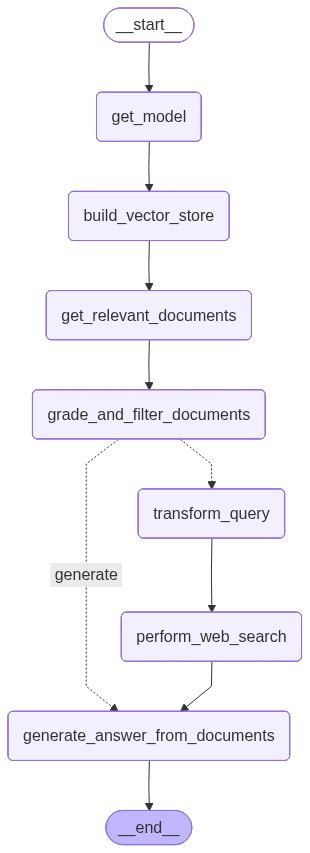

In [28]:
from IPython.display import Image
Image(compiled_graph.get_graph().draw_mermaid_png())